In [2]:
import pandas as pd


In [5]:
df = pd.read_csv("financial_fraud_detection_dataset.csv")
df.describe()


,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


In [6]:
print(df.isnull().sum())

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [8]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [9]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
False    4820447
True      179553
Name: count, dtype: int64
is_fraud
False    96.40894
True      3.59106
Name: proportion, dtype: float64


In [16]:
print(df['fraud_type'].value_counts())


fraud_type
Not Fraud           4820447
card_not_present     179553
Name: count, dtype: int64


In [11]:
print(df['transaction_type'].value_counts())
print(df['merchant_category'].value_counts())
print(df['payment_channel'].value_counts())
print(df['device_used'].value_counts())

transaction_type
deposit       1250593
payment       1250438
transfer      1250334
withdrawal    1248635
Name: count, dtype: int64
merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64
payment_channel
wire_transfer    1251219
ACH              1250241
card             1249693
UPI              1248847
Name: count, dtype: int64
device_used
mobile    1251131
web       1250071
atm       1249640
pos       1249158
Name: count, dtype: int64


In [13]:
print(df.groupby('is_fraud')['amount'].mean())

is_fraud
False    358.949394
True     358.528199
Name: amount, dtype: float64


In [17]:
# Step 1 — Fill missing values
df['fraud_type'] = df['fraud_type'].fillna('Not Fraud')
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(df['time_since_last_transaction'].median())

# Step 2 — Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')

# Step 3 — Check for duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Step 4 — Confirm no more missing values
print(df.isnull().sum())

# Step 5 — Save your clean file
df.to_csv('fraud_clean.csv', index=False)
print("Clean file saved!")


Duplicates: 0
transaction_id                 0
timestamp                      0
sender_account                 0
receiver_account               0
amount                         0
transaction_type               0
merchant_category              0
location                       0
device_used                    0
is_fraud                       0
fraud_type                     0
time_since_last_transaction    0
spending_deviation_score       0
velocity_score                 0
geo_anomaly_score              0
payment_channel                0
ip_address                     0
device_hash                    0
dtype: int64
Clean file saved!


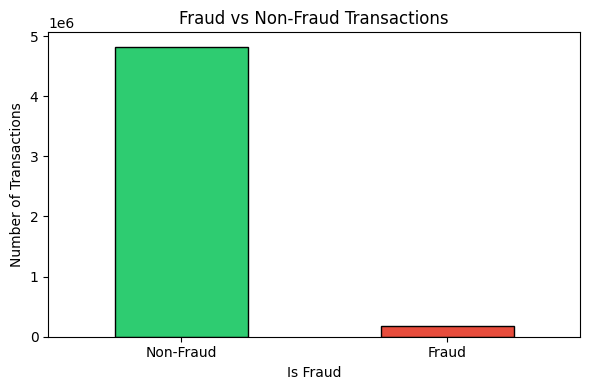

Chart 1 saved!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Fraud vs Non-Fraud count
plt.figure(figsize=(6,4))
df['is_fraud'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Number of Transactions')
plt.xticks([0,1], ['Non-Fraud','Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('chart1_fraud_count.png')
plt.show()
print("Chart 1 saved!")

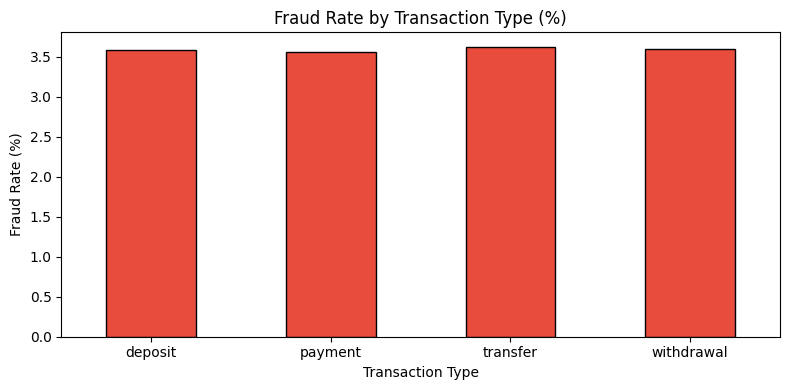

Chart 2 saved!


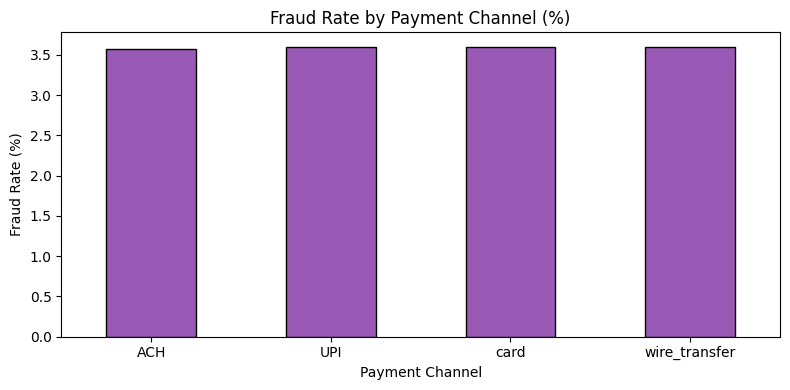

Chart 3 saved!


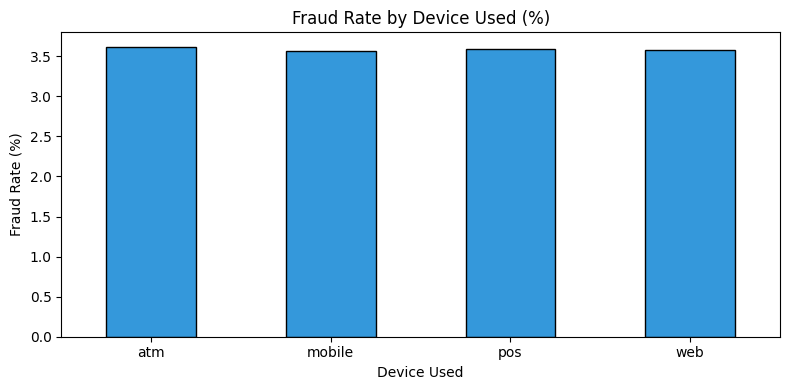

Chart 4 saved!


In [20]:
# Chart 2 — Fraud rate by transaction type
plt.figure(figsize=(8,4))
fraud_by_txn = df.groupby('transaction_type')['is_fraud'].mean() * 100
fraud_by_txn.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Fraud Rate by Transaction Type (%)')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_fraud_by_txn.png')
plt.show()
print("Chart 2 saved!")

# Chart 3 — Fraud rate by payment channel
plt.figure(figsize=(8,4))
fraud_by_channel = df.groupby('payment_channel')['is_fraud'].mean() * 100
fraud_by_channel.plot(kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Fraud Rate by Payment Channel (%)')
plt.xlabel('Payment Channel')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_fraud_by_channel.png')
plt.show()
print("Chart 3 saved!")

# Chart 4 — Fraud rate by device used
plt.figure(figsize=(8,4))
fraud_by_device = df.groupby('device_used')['is_fraud'].mean() * 100
fraud_by_device.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Fraud Rate by Device Used (%)')
plt.xlabel('Device Used')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_fraud_by_device.png')
plt.show()
print("Chart 4 saved!")

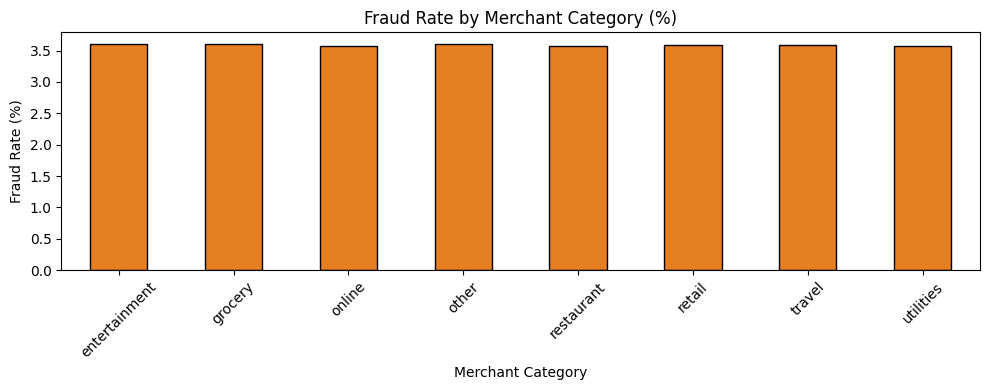

Chart 5 saved!


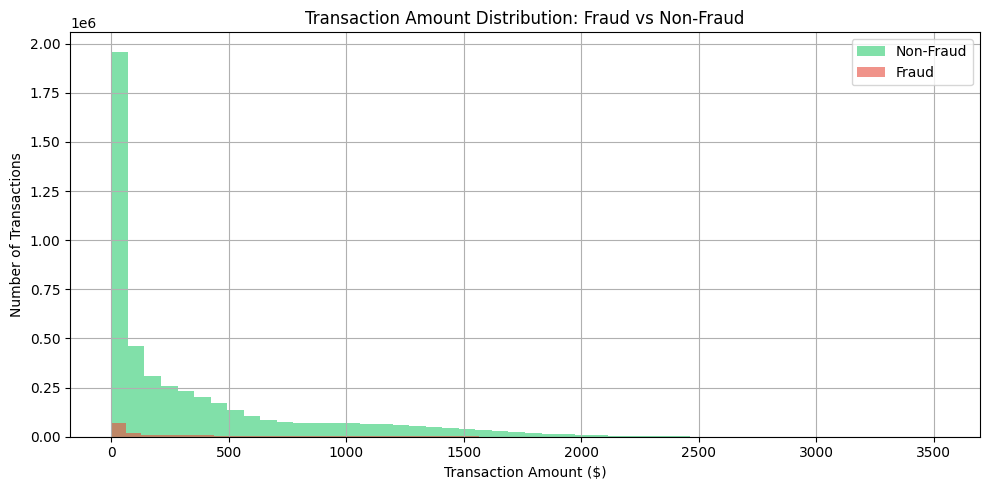

Chart 6 saved!


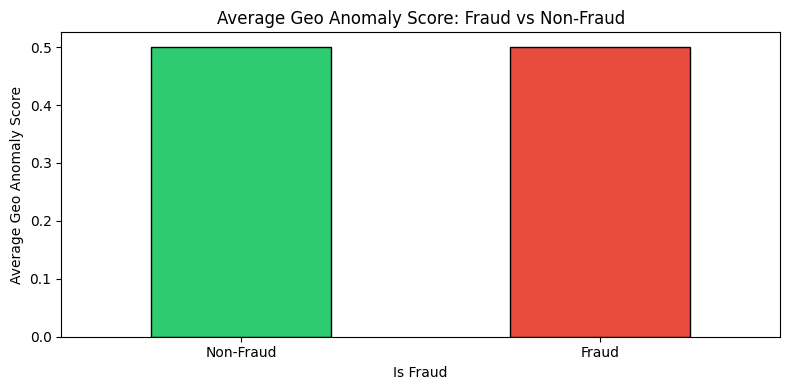

Chart 7 saved!


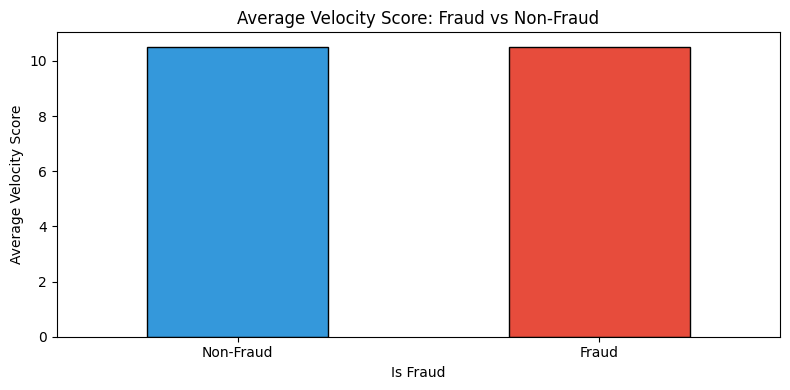

Chart 8 saved!


In [21]:
# Chart 5 — Fraud rate by merchant category
plt.figure(figsize=(10,4))
fraud_by_merchant = df.groupby('merchant_category')['is_fraud'].mean() * 100
fraud_by_merchant.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Fraud Rate by Merchant Category (%)')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_fraud_by_merchant.png')
plt.show()
print("Chart 5 saved!")

# Chart 6 — Transaction amount distribution: fraud vs non-fraud
plt.figure(figsize=(10,5))
df[df['is_fraud']==False]['amount'].hist(bins=50, alpha=0.6, color='#2ecc71', label='Non-Fraud')
df[df['is_fraud']==True]['amount'].hist(bins=50, alpha=0.6, color='#e74c3c', label='Fraud')
plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_amount_distribution.png')
plt.show()
print("Chart 6 saved!")

# Chart 7 — Geo anomaly score vs fraud
plt.figure(figsize=(8,4))
df.groupby('is_fraud')['geo_anomaly_score'].mean().plot(
    kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black')
plt.title('Average Geo Anomaly Score: Fraud vs Non-Fraud')
plt.xlabel('Is Fraud')
plt.ylabel('Average Geo Anomaly Score')
plt.xticks([0,1], ['Non-Fraud','Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('chart7_geo_anomaly.png')
plt.show()
print("Chart 7 saved!")

# Chart 8 — Velocity score vs fraud
plt.figure(figsize=(8,4))
df.groupby('is_fraud')['velocity_score'].mean().plot(
    kind='bar', color=['#3498db','#e74c3c'], edgecolor='black')
plt.title('Average Velocity Score: Fraud vs Non-Fraud')
plt.xlabel('Is Fraud')
plt.ylabel('Average Velocity Score')
plt.xticks([0,1], ['Non-Fraud','Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('chart8_velocity_score.png')
plt.show()
print("Chart 8 saved!")

In [22]:
from scipy import stats

print("=" * 55)
print("HYPOTHESIS TESTING")
print("=" * 55)

# H1 — Does transaction amount differ between fraud and non-fraud?
fraud_amounts = df[df['is_fraud']==True]['amount']
non_fraud_amounts = df[df['is_fraud']==False]['amount']
t_stat, p_value = stats.ttest_ind(fraud_amounts, non_fraud_amounts)
print("\nH1: Transaction amount is equal for fraud and non-fraud")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: REJECT null hypothesis — amounts ARE significantly different")
else:
    print("Result: FAIL TO REJECT null hypothesis — amounts are NOT significantly different")

# H2 — Does geo anomaly score differ between fraud and non-fraud?
fraud_geo = df[df['is_fraud']==True]['geo_anomaly_score']
non_fraud_geo = df[df['is_fraud']==False]['geo_anomaly_score']
t_stat2, p_value2 = stats.ttest_ind(fraud_geo, non_fraud_geo)
print("\nH2: Geo anomaly score is equal for fraud and non-fraud")
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
if p_value2 < 0.05:
    print("Result: REJECT null hypothesis — geo scores ARE significantly different")
else:
    print("Result: FAIL TO REJECT null hypothesis — geo scores are NOT significantly different")

# H3 — Does velocity score differ between fraud and non-fraud?
fraud_vel = df[df['is_fraud']==True]['velocity_score']
non_fraud_vel = df[df['is_fraud']==False]['velocity_score']
t_stat3, p_value3 = stats.ttest_ind(fraud_vel, non_fraud_vel)
print("\nH3: Velocity score is equal for fraud and non-fraud")
print(f"T-statistic: {t_stat3:.4f}")
print(f"P-value: {p_value3:.4f}")
if p_value3 < 0.05:
    print("Result: REJECT null hypothesis — velocity scores ARE significantly different")
else:
    print("Result: FAIL TO REJECT null hypothesis — velocity scores are NOT significantly different")

print("\n" + "=" * 55)
print("Hypothesis testing complete!")

HYPOTHESIS TESTING

H1: Transaction amount is equal for fraud and non-fraud
T-statistic: -0.3729
P-value: 0.7092
Result: FAIL TO REJECT null hypothesis — amounts are NOT significantly different

H2: Geo anomaly score is equal for fraud and non-fraud
T-statistic: 0.6948
P-value: 0.4872
Result: FAIL TO REJECT null hypothesis — geo scores are NOT significantly different

H3: Velocity score is equal for fraud and non-fraud
T-statistic: 0.8275
P-value: 0.4079
Result: FAIL TO REJECT null hypothesis — velocity scores are NOT significantly different

Hypothesis testing complete!


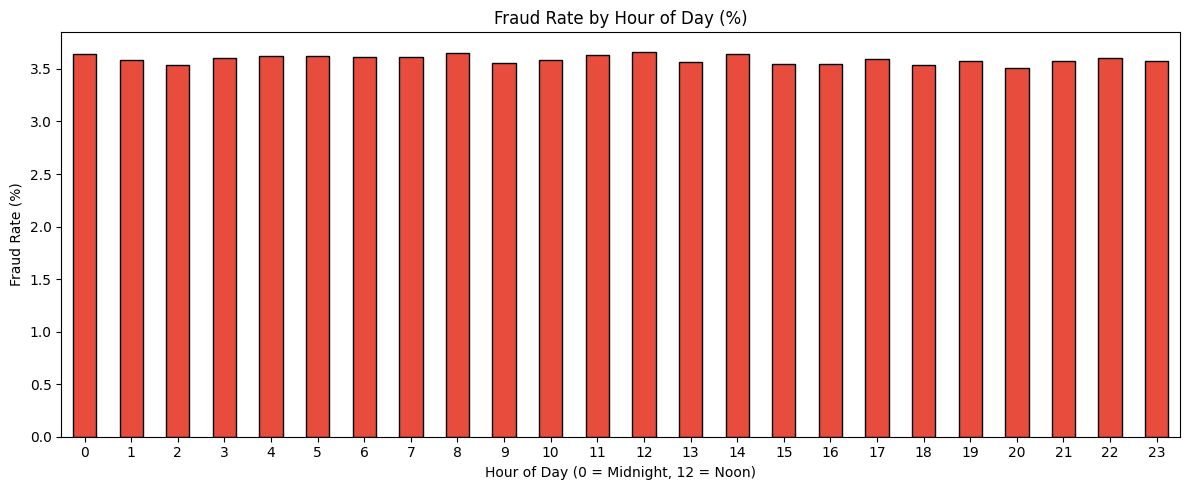

Chart 9 saved!


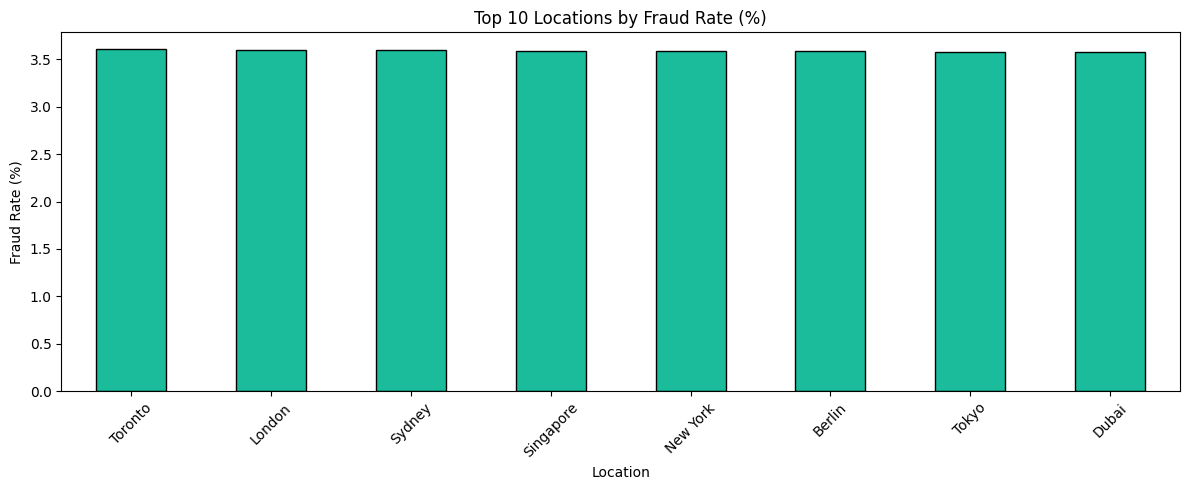

Chart 10 saved!


In [23]:
# Chart 9 — Fraud by hour of day
df['hour'] = df['timestamp'].dt.hour
plt.figure(figsize=(12,5))
fraud_by_hour = df[df['is_fraud']==True].groupby('hour').size()
total_by_hour = df.groupby('hour').size()
fraud_rate_by_hour = (fraud_by_hour / total_by_hour * 100).fillna(0)
fraud_rate_by_hour.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Fraud Rate by Hour of Day (%)')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart9_fraud_by_hour.png')
plt.show()
print("Chart 9 saved!")

# Chart 10 — Fraud by location (top 10)
plt.figure(figsize=(12,5))
fraud_by_location = df.groupby('location')['is_fraud'].mean() * 100
fraud_by_location.sort_values(ascending=False).head(10).plot(
    kind='bar', color='#1abc9c', edgecolor='black')
plt.title('Top 10 Locations by Fraud Rate (%)')
plt.xlabel('Location')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart10_fraud_by_location.png')
plt.show()
print("Chart 10 saved!")